## 45 Years of the S&P 500: Does Time Heal All Market Bubbles?
*Part 2 of a series — Part 1 compared the current AI-driven rally to the dot-com bubble.*

**TL;DR** (45 years of S&P 500 history, 1978-present — a data-driven cutoff to exclude the pre-modern-market era):
- No holding period of **14 years or longer** has ever ended in a historical loss - though loss risk isn't perfectly monotonic, briefly rising again around years 5 and 11 before settling to zero.
- 10-year holds: median return +169%, but not guaranteed - 6.1% ended in a loss, worst case -47%.
- 20-year holds: median return +337%, with a 0% historical loss rate.
- The five major crashes since 1978 (1980, 1987, dot-com, GFC, COVID) took anywhere from 0.5 to 7.2 years to fully recover in isolation - but the dot-com and GFC crashes overlapped closely enough that a buy-and-hold investor could get caught by both, which is why 14 years, not ~7, is the actual "safe" threshold.
- Most crashes were slow grinds lasting weeks to years - except 1987 Black Monday, which did most of its damage in a single -20.5% day.

**Limitations:** these figures are nominal (not inflation-adjusted), assume true buy-and-hold with no forced selling during downturns, and reflect one market's history (the U.S.) - results may not generalize elsewhere.


In Part 1, we compared the current AI-driven S&P 500 rally to the dot-com bubble of the late 1990s and early 2000s - looking at shape, volatility, correlation, and drawdowns. But zooming into day-to-day dynamics only tells part of the story. As a private investor, what we fear most isn't a rough day or a bad week - it's a crash: a sustained, multi-year downslope that erodes the value of a portfolio for far longer than any single sell-off. However similar or different two booms look up close, how much do bubbles actually matter to someone who just holds through them? Let's look at 45 years of S&P 500 history to find out.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.dates as mdates

### Visualize the whole S&P 500 history (weekly)

Cookie fetch from fc.yahoo.com failed (CertificateVerifyError), continuing without it
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
[*********************100%***********************]  1 of 1 completed


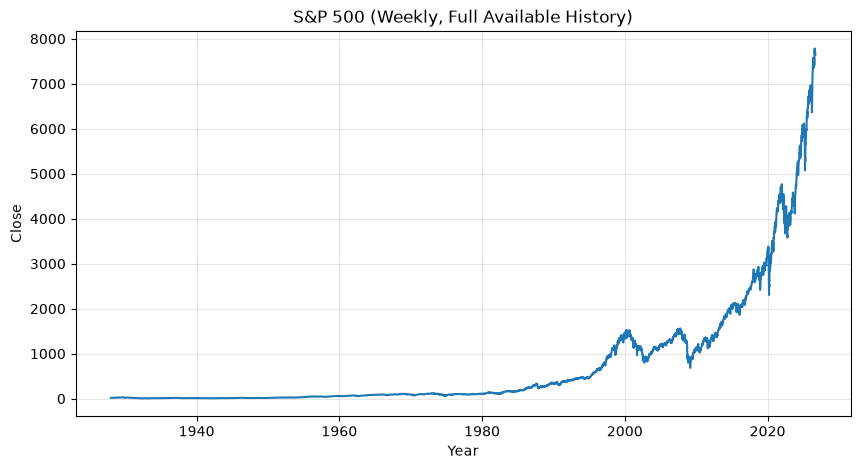

Earliest available data point: 1927-12-26


In [3]:
# Full available S&P 500 history (as far back as Yahoo Finance has data), just for visual context
sp500_max_history = yf.download(
    "^GSPC",
    period="max",
    interval="1wk",
    auto_adjust=True
)

plt.figure(figsize=(10, 5))
plt.plot(sp500_max_history.index, sp500_max_history["Close"])
plt.title("S&P 500 (Weekly, Full Available History)")
plt.xlabel("Year")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Earliest available data point: {sp500_max_history.index.min().date()}")

On a linear scale, early history is squashed flat by how much larger the index is today - a log scale instead makes equal *percentage* moves look the same size regardless of era, so long-run growth rates become directly comparable:

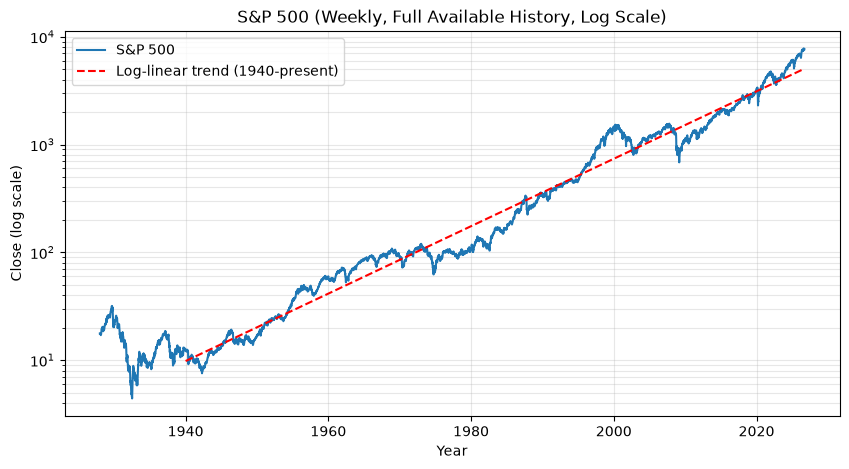

In [4]:
# Same full history, log scale (makes long-run % growth comparable across eras)
log_price = np.log(sp500_max_history["Close"]).squeeze()
years_since_start = (sp500_max_history.index - sp500_max_history.index[0]).days / 365.25

# Fit the trend on 1940-onward only, so the Depression-era years don't skew it
fit_mask = sp500_max_history.index >= pd.Timestamp("1940-01-01")
overall_slope, overall_intercept = np.polyfit(years_since_start[fit_mask], log_price[fit_mask], 1)
overall_trend = np.exp(overall_intercept + overall_slope * years_since_start[fit_mask])

plt.figure(figsize=(10, 5))
plt.plot(sp500_max_history.index, sp500_max_history["Close"], label="S&P 500")
plt.plot(sp500_max_history.index[fit_mask], overall_trend, color="red", linestyle="--", label="Log-linear trend (1940-present)")
plt.yscale("log")
plt.title("S&P 500 (Weekly, Full Available History, Log Scale)")
plt.xlabel("Year")
plt.ylabel("Close (log scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


On a log scale, the S&P 500 looks roughly like a straight line for most of its history - except at the very beginning (pre-1940s), where it visibly bends away from that line.

That bend is more than a statistical quirk - the market (and the economy around it) in the 1940s-50s operated under a genuinely different regime: different regulation, different monetary policy, no modern index funds or electronic trading, and a market still recovering from the Depression and World War II. Mixing that era in with the modern market would skew any deeper analysis of holding periods and crash recovery. So instead of picking a cutoff year by eye, let's find one the data itself supports.


### Finding a data-driven cutoff year

In [5]:
# Try candidate cutoff years every 2 years, compare pre/post trend growth rates for each
candidate_years = range(1950, 2005, 2)

cutoff_years, pre_rates, post_rates, gaps = [], [], [], []

for year in candidate_years:
    candidate_cutoff = pd.Timestamp(f"{year}-01-01")
    c_pre_mask = sp500_max_history.index < candidate_cutoff
    c_post_mask = ~c_pre_mask

    if c_pre_mask.sum() < 104 or c_post_mask.sum() < 104:
        continue

    c_slope_pre, _ = np.polyfit(years_since_start[c_pre_mask], log_price[c_pre_mask], 1)
    c_slope_post, _ = np.polyfit(years_since_start[c_post_mask], log_price[c_post_mask], 1)

    pre_rate = (np.exp(c_slope_pre) - 1) * 100
    post_rate = (np.exp(c_slope_post) - 1) * 100

    cutoff_years.append(year)
    pre_rates.append(pre_rate)
    post_rates.append(post_rate)
    gaps.append(post_rate - pre_rate)


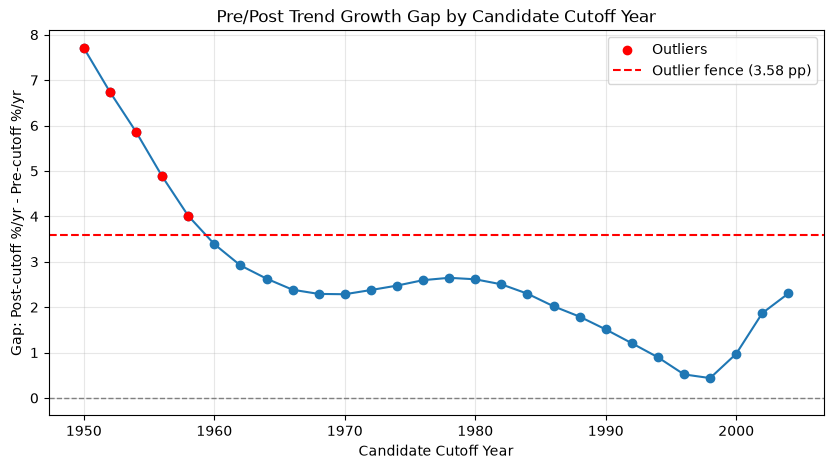

Outlier fence (Q3 + 1.0*IQR): 3.58 pp
Cutoff years flagged as outliers: [1950, 1952, 1954, 1956, 1958]
Candidate cutoff year with the largest gap (excluding outliers): 1960 (gap = 3.39 pp)


In [6]:
# Plot the pre/post trend growth gap across candidate cutoff years
gaps_arr = np.array(gaps)
q1, q3 = np.percentile(gaps_arr, [25, 75])
iqr = q3 - q1
outlier_fence = q3 + 1.0 * iqr  # A tighter 1.0×IQR upper fence was used to identify moderately unusual gaps,

is_outlier = gaps_arr > outlier_fence

plt.figure(figsize=(10, 5))
plt.plot(cutoff_years, gaps, marker="o")
plt.scatter(np.array(cutoff_years)[is_outlier], gaps_arr[is_outlier], color="red", zorder=5, label="Outliers")
plt.axhline(0, color="gray", linewidth=1, linestyle="--")
plt.axhline(outlier_fence, color="red", linewidth=1.5, linestyle="--", label=f"Outlier fence ({outlier_fence:.2f} pp)")
plt.title("Pre/Post Trend Growth Gap by Candidate Cutoff Year")
plt.xlabel("Candidate Cutoff Year")
plt.ylabel("Gap: Post-cutoff %/yr - Pre-cutoff %/yr")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Outlier fence (Q3 + 1.0*IQR): {outlier_fence:.2f} pp")
print(f"Cutoff years flagged as outliers: {np.array(cutoff_years)[is_outlier].tolist()}")

# Confirm 1978 is actually the local max gap among the non-outlier candidate years
non_outlier_years = np.array(cutoff_years)[~is_outlier]
non_outlier_gaps = gaps_arr[~is_outlier]
best_year = non_outlier_years[np.argmax(non_outlier_gaps)]
print(f"Candidate cutoff year with the largest gap (excluding outliers): {best_year} (gap = {non_outlier_gaps.max():.2f} pp)")


**First-stage filter:** cutoffs before 1960 get excluded - they only have a handful of years to compare against, and those years include the Depression and WWII, so their gap is just noise, not a real regime change. **Final cutoff: 1978.** Within the remaining 1960-2004 pool, the gap curve peaks in a hump around 1976-1980, with 1978 as the local maximum - roughly where the 1970s stagflation/oil-shock era gives way to a more modern market regime. Tying 1978 to that narrative is one interpretation, but the cutoff itself comes straight from where the data peaks, not from picking a year by eye.

### Rolling Returns by Holding Period Since 1978

With 1978 established as the cutoff, we now switch from the full historical dataset to just this filtered window to study rolling returns - starting with the common 10- and 20-year benchmarks, then generalizing to every whole-year holding period in between.

In [7]:
# S&P 500, full history, weekly resolution
sp500_weekly = yf.download(
    "^GSPC",
    start="1978-01-01",
    interval="1wk",
    auto_adjust=True
)

print(sp500_weekly.tail())

Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC
Date                                                                       
2026-08-16  7674.370117  7790.680176  7639.009766  7790.680176  23496310000
2026-08-23  7711.759766  7771.479980  7638.169922  7663.379883  21421440000
2026-08-30  7718.600098  7756.759766  7611.200195  7697.520020  23813150000
2026-09-06  7656.979980  7717.810059  7580.060059  7717.810059  19479850000
2026-09-13  7650.500000  7657.169922  7507.770020  7611.439941  29343160000


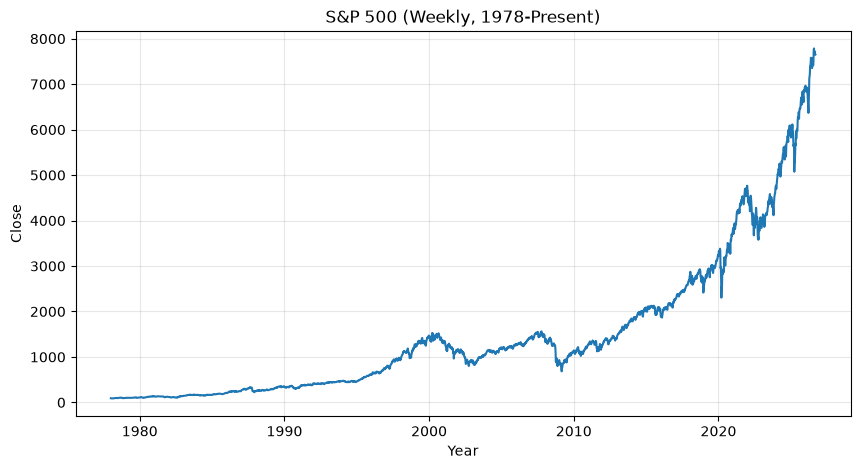

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(sp500_weekly.index, sp500_weekly["Close"])
plt.title("S&P 500 (Weekly, 1978-Present)")
plt.xlabel("Year")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.show()

Though there are bubbles and ups and downs along the way, the index recovers in the long run and shows an increasing trend over a long time horizon.

In [9]:
# Rolling 10-year return using the full weekly history (52 weeks/year)
window = 52 * 10
sp500_10y_return = sp500_weekly["Close"].pct_change(periods=window)

print(sp500_10y_return.dropna().describe())

Ticker        ^GSPC
count   2022.000000
mean       1.506020
std        0.899172
min       -0.474036
25%        0.754584
50%        1.688782
75%        2.030524
max        3.800527


In [10]:
# Rolling 20-year return using the full weekly history (52 weeks/year)
window_20y = 52 * 20
sp500_20y_return = sp500_weekly["Close"].pct_change(periods=window_20y)

print(sp500_20y_return.dropna().describe())

Ticker        ^GSPC
count   1502.000000
mean       4.297803
std        2.904305
min        0.699092
25%        2.259019
50%        3.373041
75%        5.125461
max       14.191048


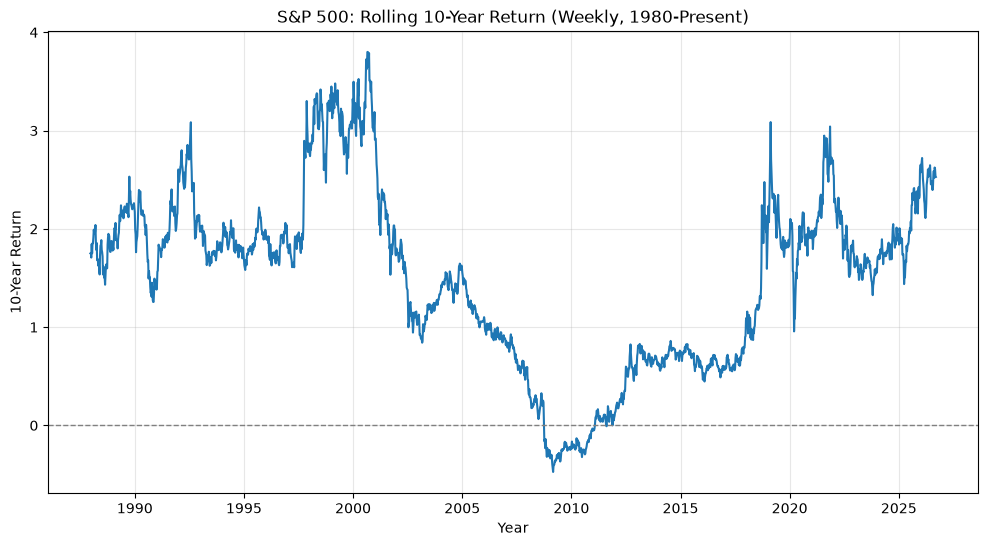

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(sp500_10y_return.index, sp500_10y_return)
plt.axhline(0, color="gray", linewidth=1, linestyle="--")

plt.title("S&P 500: Rolling 10-Year Return (Weekly, 1980-Present)")
plt.xlabel("Year")
plt.ylabel("10-Year Return")
plt.grid(True, alpha=0.3)

plt.show()

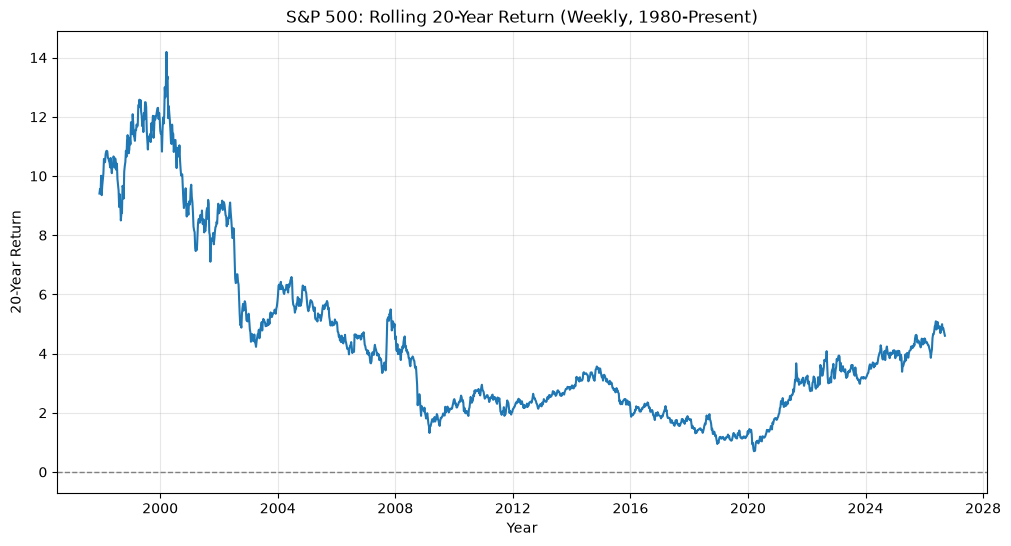

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(sp500_20y_return.index, sp500_20y_return)
plt.axhline(0, color="gray", linewidth=1, linestyle="--")

plt.title("S&P 500: Rolling 20-Year Return (Weekly, 1980-Present)")
plt.xlabel("Year")
plt.ylabel("20-Year Return")
plt.grid(True, alpha=0.3)

plt.show()

In [13]:
# Historical frequency of gain/loss across all overlapping 10-year windows since 1980
# (windows overlap heavily so this is a descriptive historical frequency, not an independent-sample probability)
returns_10y = sp500_10y_return.dropna().squeeze()
loss_rate = float((returns_10y < 0).mean() * 100)
gain_rate = 100 - loss_rate
avg_loss_when_negative = float(returns_10y[returns_10y < 0].mean() * 100)
avg_gain_when_positive = float(returns_10y[returns_10y > 0].mean() * 100)

print(f"10-year windows ending in a loss: {loss_rate:.1f}% (average loss: {avg_loss_when_negative:.1f}%)")
print(f"10-year windows ending in a gain: {gain_rate:.1f}% (average gain: {avg_gain_when_positive:.1f}%)")

10-year windows ending in a loss: 6.1% (average loss: -23.2%)
10-year windows ending in a gain: 93.9% (average gain: 161.9%)


In [14]:
# Historical frequency of gain/loss across all overlapping 20-year windows since 1980
# (windows overlap heavily so this is a descriptive historical frequency, not an independent-sample probability)
returns_20y = sp500_20y_return.dropna().squeeze()
loss_rate_20y = float((returns_20y < 0).mean() * 100)
gain_rate_20y = 100 - loss_rate_20y
avg_loss_when_negative_20y = float(returns_20y[returns_20y < 0].mean() * 100) if loss_rate_20y > 0 else None
avg_gain_when_positive_20y = float(returns_20y[returns_20y > 0].mean() * 100)

print(f"20-year windows ending in a loss: {loss_rate_20y:.1f}%")
print(f"20-year windows ending in a gain: {gain_rate_20y:.1f}% (average gain: {avg_gain_when_positive_20y:.1f}%)")

20-year windows ending in a loss: 0.0%
20-year windows ending in a gain: 100.0% (average gain: 429.8%)


**What this means for a 10-year hold in the S&P 500 (1978-present):**

*All figures below are derived purely from historical data — they describe what has happened, not a prediction or guarantee of future returns. They are also nominal returns, not adjusted for inflation, so real purchasing power gained is lower than the percentages below.*
- **Median return: +169%** — the typical 10-year outcome roughly triples your money.
- **Worst case: -47%** — even over 10 years, a bad entry point can still lose you money.
- **Best case: +380%** — the best 10-year windows nearly quadruple money on top of the starting amount.
- **Middle 50% of outcomes: +76% to +203%** — most 10-year holds land well in positive territory, so time in the market has historically smoothed out short-term bubbles and crashes.
- **Historically, 93.9% of 10-year holds ended in a gain (avg. +161.9%) and 6.1% ended in a loss (avg. -23.2%).** This is a historical frequency, not a statistical probability — the windows overlap heavily (each one shares most of its 10 years with its neighbors), so they aren't independent samples and the future isn't guaranteed to repeat this pattern.

**And for a 20-year hold:**
- **Median return: +337%** — roughly quadrupling your money over 20 years, typically.
- **Worst case so far: +70%** — every single 20-year window since 1980 has ended positive.
- **Best case: +1419%** — the best 20-year windows turned an initial investment into more than 15x.
- **Middle 50% of outcomes: +126% to +413%** — the vast majority of 20-year holds land well into triple-digit gains.
- **Historically, 100% of 20-year holds ended in a gain (avg. +429.8%), with 0% ending in a loss.** Same caveat as above: this reflects overlapping historical windows, not an independent-sample probability, and it's a smaller, more extreme-value-sensitive sample than the 10-year data.


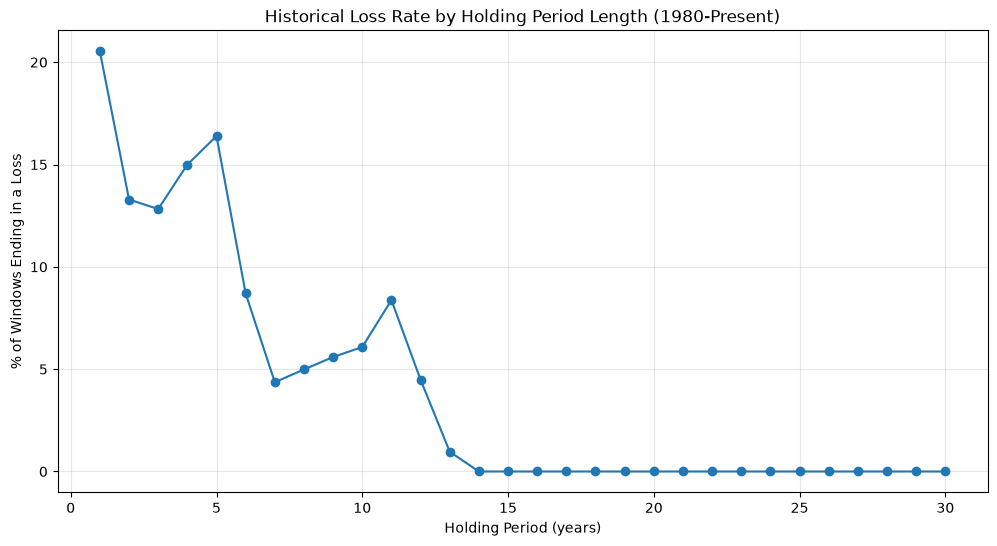

Loss rate at 1 year: 20.5%
Loss rate at 10 years: 6.1%
Loss rate at 14 years: 0.0%
Loss rate at 20 years: 0.0%
Is it monotonically non-increasing from year 1 to 30? False
Shortest holding period with no historical losses: 14 years


In [15]:
# Loss rate for every whole-year holding period (not just 10 and 20), to check if "longer = safer" actually holds throughout
loss_rate_by_years = []
for years in range(1, 31):
    returns_y = sp500_weekly["Close"].pct_change(periods=52 * years).dropna().squeeze()
    loss_rate_by_years.append((returns_y < 0).mean() * 100)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 31), loss_rate_by_years, marker="o")
plt.title("Historical Loss Rate by Holding Period Length (1980-Present)")
plt.xlabel("Holding Period (years)")
plt.ylabel("% of Windows Ending in a Loss")
plt.grid(True, alpha=0.3)
plt.show()

min_years_no_loss = next(years for years, rate in enumerate(loss_rate_by_years, start=1) if rate == 0)

print(f"Loss rate at 1 year: {loss_rate_by_years[0]:.1f}%")
print(f"Loss rate at 10 years: {loss_rate_by_years[9]:.1f}%")
print(f"Loss rate at 14 years: {loss_rate_by_years[13]:.1f}%")
print(f"Loss rate at 20 years: {loss_rate_by_years[19]:.1f}%")
print(f"Is it monotonically non-increasing from year 1 to 30? {all(x >= y for x, y in zip(loss_rate_by_years, loss_rate_by_years[1:]))}")
print(f"Shortest holding period with no historical losses: {min_years_no_loss} years")


**Takeaway: loss risk trends downward with longer holds, but not smoothly.** The full year-by-year curve above shows the loss rate is noisy in the short-to-medium range (it briefly rises again around 5 and 11 years) rather than shrinking in a straight line - so "longer is always safer" isn't strictly true. What is true in this data: 10-year windows had a 6.1% loss rate (avg. -23.2%), 20-year windows had 0% (avg. +429.8%), and **14 years** is the shortest holding period where the loss rate first hits zero and stays there through year 30.


Why 14 years specifically? The likely answer is the handful of severe, multi-year crashes baked into this history - the exact downturns investors fear most. The next section looks at those crashes directly: how deep they got, and how long it actually took to recover.


### Crash and recovery analysis

That's the risk this section tries to measure directly: how deep did the major historical crashes get, and how long did it actually take to get back to even?

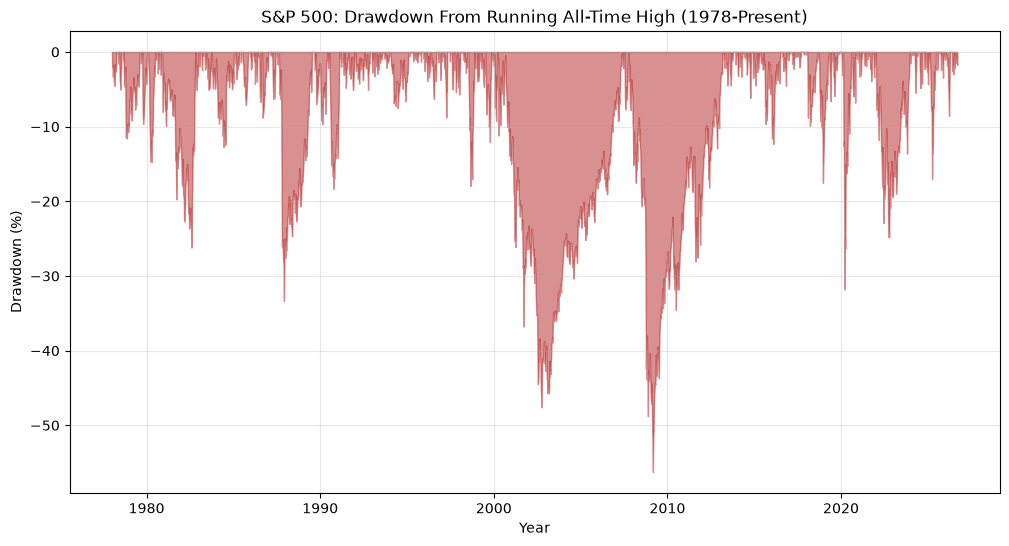

In [16]:
# Drawdown from running all-time high, 1978-present ("underwater" chart)
running_peak = sp500_weekly["Close"].cummax()
drawdown = (sp500_weekly["Close"] / running_peak - 1).squeeze()

plt.figure(figsize=(12, 6))
plt.fill_between(drawdown.index, drawdown * 100, 0, color="firebrick", alpha=0.5)
plt.title("S&P 500: Drawdown From Running All-Time High (1978-Present)")
plt.xlabel("Year")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
# Peak, trough, max drawdown, and recovery time for every crash since 1978, detected algorithmically
# rather than hand-picked: a "crash" is any drawdown of at least 25% from a prior all-time high
# (stricter than the -20% "bear market" convention, to isolate severe crashes rather than routine
# corrections), with double-dips before a new high merged into one episode.
crash_threshold = -0.25

close = sp500_weekly["Close"].squeeze()
running_peak = close.cummax()
drawdown_series = close / running_peak - 1

in_crash = drawdown_series <= crash_threshold
episode_id = (in_crash != in_crash.shift(fill_value=False)).cumsum()

raw_episodes = []
for ep_id in episode_id[in_crash].unique():
    episode_dates = drawdown_series.index[episode_id == ep_id]
    trough_date = close.loc[episode_dates].idxmin()
    trough_price = close.loc[trough_date]

    peak_price_series = close.loc[:trough_date]
    peak_date = peak_price_series.idxmax()
    peak_price = peak_price_series.max()

    max_drawdown = trough_price / peak_price - 1
    time_to_trough = (trough_date - peak_date).days / 365.25

    after_trough = close.loc[trough_date:]
    recovered = after_trough[after_trough >= peak_price]
    recovery_date = recovered.index[0] if not recovered.empty else None
    time_to_recover = (recovery_date - peak_date).days / 365.25 if recovery_date is not None else None

    raw_episodes.append({
        "name": f"{peak_date.year} crash", "peak_date": peak_date, "peak_price": peak_price,
        "trough_date": trough_date, "max_drawdown": max_drawdown, "time_to_trough": time_to_trough,
        "recovery_date": recovery_date, "time_to_recover": time_to_recover,
    })

# Merge episodes sharing the same peak (no new all-time high in between = same underlying crash)
merged_by_peak = {}
for episode in raw_episodes:
    key = episode["peak_date"]
    if key not in merged_by_peak or episode["max_drawdown"] < merged_by_peak[key]["max_drawdown"]:
        merged_by_peak[key] = episode
crash_stats = sorted(merged_by_peak.values(), key=lambda e: e["peak_date"])

print(f"{'Crash':>25} | {'Peak date':>10} | {'Trough date':>11} | {'Max drawdown':>12} | {'Peak-to-trough':>14} | {'Recovery date':>13} | {'Peak-to-recovery':>16}")
for stat in crash_stats:
    recovery_str = stat["recovery_date"].date().isoformat() if stat["recovery_date"] is not None else "not yet"
    time_to_recover_str = f"{stat['time_to_recover']:.1f} yrs" if stat["time_to_recover"] is not None else "N/A"
    print(f"{stat['name']:>25} | {stat['peak_date'].date()} | {stat['trough_date'].date()} | {stat['max_drawdown'] * 100:>11.1f}% | {stat['time_to_trough']:>13.1f}y | {recovery_str:>13} | {time_to_recover_str:>16}")

# Summary stats on peak-to-trough and peak-to-recovery duration across the crashes
peak_to_trough_years = pd.Series([c["time_to_trough"] for c in crash_stats], index=[c["name"] for c in crash_stats])
peak_to_recovery_years = pd.Series([c["time_to_recover"] for c in crash_stats], index=[c["name"] for c in crash_stats]).dropna()

print(f"\nAverage peak-to-trough duration: {peak_to_trough_years.mean():.1f} yrs")
print(f"Median peak-to-trough duration: {peak_to_trough_years.median():.1f} yrs")
print(f"Shortest: {peak_to_trough_years.idxmin()} ({peak_to_trough_years.min():.1f} yrs)")
print(f"Longest: {peak_to_trough_years.idxmax()} ({peak_to_trough_years.max():.1f} yrs)")

print(f"\nAverage peak-to-recovery duration: {peak_to_recovery_years.mean():.1f} yrs")
print(f"Median peak-to-recovery duration: {peak_to_recovery_years.median():.1f} yrs")
print(f"Shortest: {peak_to_recovery_years.idxmin()} ({peak_to_recovery_years.min():.1f} yrs)")
print(f"Longest: {peak_to_recovery_years.idxmax()} ({peak_to_recovery_years.max():.1f} yrs)")


                    Crash |  Peak date | Trough date | Max drawdown | Peak-to-trough | Recovery date | Peak-to-recovery
               1980 crash | 1980-11-23 | 1982-08-01 |       -26.2% |           1.7y |    1982-10-31 |          1.9 yrs
               1987 crash | 1987-08-16 | 1987-11-29 |       -33.3% |           0.3y |    1989-07-16 |          1.9 yrs
               2000 crash | 2000-03-19 | 2002-09-29 |       -47.6% |           2.5y |    2007-05-27 |          7.2 yrs
               2007 crash | 2007-10-07 | 2009-03-01 |       -56.2% |           1.4y |    2013-03-24 |          5.5 yrs
               2020 crash | 2020-02-09 | 2020-03-15 |       -31.8% |           0.1y |    2020-08-16 |          0.5 yrs

Average peak-to-trough duration: 1.2 yrs
Median peak-to-trough duration: 1.4 yrs
Shortest: 2020 crash (0.1 yrs)
Longest: 2000 crash (2.5 yrs)

Average peak-to-recovery duration: 3.4 yrs
Median peak-to-recovery duration: 1.9 yrs
Shortest: 2020 crash (0.5 yrs)
Longest: 2000 crash (7.2 

**Recovery from each crash, taken in isolation, was always well under a decade** (fastest: COVID at 0.5 years; slowest: the dot-com bust at 7.2 years). But that isolated view is optimistic: the dot-com recovery didn't complete until May 2007, and the GFC crash hit just five months later - so anyone who bought in the years between those two peaks could get caught by the second crash before ever banking the first recovery. That overlap, not any single crash, is why the earlier "shortest holding period with zero historical losses" came out to 14 years rather than ~7 - it's the chained worst case, not the average one.

**So does time heal all market bubbles?** Largely yes, within the limits of this dataset — much like a cut or a broken bone in a person, an animal, or a plant, the market's wounds close on their own, but only given enough time. That's exactly what the 14-year "zero historical losses" finding is showing: any crash or bubble, however severe on impact, has historically been absorbed into the market's long-run upward trend given enough holding time.*

**Same caveats as above apply here too:** true buy-and-hold, and nominal (not inflation-adjusted) returns.

In [18]:
# How fast did each crash actually move, day-to-day? (weekly data hides single-day moves, so fetch daily)
sp500_daily = yf.download("^GSPC", start="1978-01-01", interval="1d", auto_adjust=True)["Close"].squeeze()
daily_returns = sp500_daily.pct_change().dropna() * 100

print(f"{'Crash':>25} | {'Worst single day':>16} | {'Avg daily move':>14} | {'Daily volatility (std)':>22}")
for stat in crash_stats:
    crash_daily_returns = daily_returns.loc[stat["peak_date"]:stat["trough_date"]]
    worst_day = crash_daily_returns.min()
    avg_daily = crash_daily_returns.mean()
    daily_vol = crash_daily_returns.std()

    print(f"{stat['name']:>25} | {worst_day:>15.1f}% | {avg_daily:>13.2f}% | {daily_vol:>21.2f}%")


Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
[*********************100%***********************]  1 of 1 completed

                    Crash | Worst single day | Avg daily move | Daily volatility (std)
               1980 crash |            -2.9% |         -0.06% |                  0.87%
               1987 crash |           -20.5% |         -0.39% |                  3.30%
               2000 crash |            -5.8% |         -0.08% |                  1.43%
               2007 crash |            -9.0% |         -0.19% |                  2.38%
               2020 crash |            -9.5% |         -0.77% |                  4.03%


**Takeaway: most crashes are a slow grind, not an overnight collapse.** The 1980 crash, dot-com bust, GFC, and COVID crash all had worst single days well short of -10%, with modest average daily moves (-0.06% to -0.77%) spread over weeks or years. **1987 Black Monday is the outlier** - a single -20.5% day did most of the damage, showing that a genuine one-day crash is possible, just rare in this 45-year history.


### Final words

**Series so far:** In Part 1, the AI rally and the dot-com bubble looked strikingly similar in shape, but very different in their day-to-day dynamics, volatility clustering, and tail risk. Here in Part 2, the data suggests that regardless of exactly how a bubble behaves up close, patience has historically been the biggest risk-management tool available - no holding period of at least 14 years in 45 years of S&P 500 history has ever ended in a loss. Part 3 is coming next - stay tuned.

---

*This is one market's history: the U.S. happened to recover every time in this window, but not every market has - Japan's Nikkei 225 still hasn't reclaimed its 1989 peak over 30 years later.*